<a href="https://colab.research.google.com/github/ahcamachod/1921-machine-learning-clasificacion-entre-bastidores/blob/main/tecnicas_de_clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Machine Learning: Clasificación entre Bastidores**

En este notebook estaremos desarrollando varias técnicas de clasificación para un conjunto de datos de una empresa de telecomunicaciones.

En caso de que desees consultar el dataset original, este se encuentra en el siguiente enlace:
https://www.kaggle.com/datasets/mnassrib/telecom-churn-datasets?select=churn-bigml-20.csv

## Aula 1

### 1.2 Importando los datos

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

URI = '/content/drive/MyDrive/Data_Science/Bootcamp Data Science/Machine Learning - Bootcamp DS3/Machine Learning: clasificación entre bastidores/customer_churn.csv'

datos = pd.read_csv(URI)
datos.head()

,Mayor65Anos,Conyuge,Dependientes,MesesDeContrato,TelefonoFijo,VariasLineasTelefonicas,ServicioDeInternet,SeguridadOnline,BackupOnline,SeguroEnDispositivo,SoporteTecnico,TVaCable,StreamingDePeliculas,TipoDeContrato,PagoOnline,FormaDePago,CuentaMensual,Churn
0,0,Si,No,1,No,SinServicioTelefonico,DSL,No,Si,No,No,No,No,Mensual,Si,ChequeDigital,29.85,No
1,0,No,No,34,Si,No,DSL,Si,No,Si,No,No,No,Anual,No,ChequePapel,56.95,No
2,0,No,No,2,Si,No,DSL,Si,Si,No,No,No,No,Mensual,Si,ChequePapel,53.85,Si
3,0,No,No,45,No,SinServicioTelefonico,DSL,Si,No,Si,Si,No,No,Anual,No,DebitoAutomatico,42.30,No
4,0,No,No,2,Si,No,FibraOptica,No,No,No,No,No,No,Mensual,Si,ChequeDigital,70.70,Si


In [3]:
datos.shape

(7043, 18)

### 1.3 Tipos de variables

In [4]:
datos.head()

,Mayor65Anos,Conyuge,Dependientes,MesesDeContrato,TelefonoFijo,VariasLineasTelefonicas,ServicioDeInternet,SeguridadOnline,BackupOnline,SeguroEnDispositivo,SoporteTecnico,TVaCable,StreamingDePeliculas,TipoDeContrato,PagoOnline,FormaDePago,CuentaMensual,Churn
0,0,Si,No,1,No,SinServicioTelefonico,DSL,No,Si,No,No,No,No,Mensual,Si,ChequeDigital,29.85,No
1,0,No,No,34,Si,No,DSL,Si,No,Si,No,No,No,Anual,No,ChequePapel,56.95,No
2,0,No,No,2,Si,No,DSL,Si,Si,No,No,No,No,Mensual,Si,ChequePapel,53.85,Si
3,0,No,No,45,No,SinServicioTelefonico,DSL,Si,No,Si,Si,No,No,Anual,No,DebitoAutomatico,42.30,No
4,0,No,No,2,Si,No,FibraOptica,No,No,No,No,No,No,Mensual,Si,ChequeDigital,70.70,Si


In [5]:
datos.columns

Index(['Mayor65Anos', 'Conyuge', 'Dependientes', 'MesesDeContrato',
       'TelefonoFijo', 'VariasLineasTelefonicas', 'ServicioDeInternet',
       'SeguridadOnline', 'BackupOnline', 'SeguroEnDispositivo',
       'SoporteTecnico', 'TVaCable', 'StreamingDePeliculas', 'TipoDeContrato',
       'PagoOnline', 'FormaDePago', 'CuentaMensual', 'Churn'],
      dtype='object')

In [6]:
traduccion = {'Si':1, 'No':0}
datos_modificados = datos[['Conyuge', 'Dependientes',
                           'TelefonoFijo','PagoOnline','Churn']].replace(traduccion)
datos_modificados.head()

,Conyuge,Dependientes,TelefonoFijo,PagoOnline,Churn
0,1,0,0,1,0
1,0,0,1,0,0
2,0,0,1,1,1
3,0,0,0,0,0
4,0,0,1,1,1


In [7]:
datos_dummy = pd.get_dummies(datos.drop(columns=['Conyuge', 'Dependientes',
                           'TelefonoFijo','PagoOnline','Churn'], axis=1)).astype(int)
datos_dummy.head()

,Mayor65Anos,MesesDeContrato,CuentaMensual,VariasLineasTelefonicas_No,VariasLineasTelefonicas_Si,VariasLineasTelefonicas_SinServicioTelefonico,ServicioDeInternet_DSL,ServicioDeInternet_FibraOptica,ServicioDeInternet_No,SeguridadOnline_No,...,StreamingDePeliculas_No,StreamingDePeliculas_Si,StreamingDePeliculas_SinServicioDeInternet,TipoDeContrato_Anual,TipoDeContrato_Bienal,TipoDeContrato_Mensual,FormaDePago_ChequeDigital,FormaDePago_ChequePapel,FormaDePago_DebitoAutomatico,FormaDePago_TarjetaDeCredito
0,0,1,29,0,0,1,1,0,0,1,...,1,0,0,0,0,1,1,0,0,0
1,0,34,56,1,0,0,1,0,0,0,...,1,0,0,1,0,0,0,1,0,0
2,0,2,53,1,0,0,1,0,0,0,...,1,0,0,0,0,1,0,1,0,0
3,0,45,42,0,0,1,1,0,0,0,...,1,0,0,1,0,0,0,0,1,0
4,0,2,70,1,0,0,0,1,0,1,...,1,0,0,0,0,1,1,0,0,0


In [8]:
datos_final= pd.concat([datos_modificados, datos_dummy], axis=1)
datos_final.head()

,Conyuge,Dependientes,TelefonoFijo,PagoOnline,Churn,Mayor65Anos,MesesDeContrato,CuentaMensual,VariasLineasTelefonicas_No,VariasLineasTelefonicas_Si,...,StreamingDePeliculas_No,StreamingDePeliculas_Si,StreamingDePeliculas_SinServicioDeInternet,TipoDeContrato_Anual,TipoDeContrato_Bienal,TipoDeContrato_Mensual,FormaDePago_ChequeDigital,FormaDePago_ChequePapel,FormaDePago_DebitoAutomatico,FormaDePago_TarjetaDeCredito
0,1,0,0,1,0,0,1,29,0,0,...,1,0,0,0,0,1,1,0,0,0
1,0,0,1,0,0,0,34,56,1,0,...,1,0,0,1,0,0,0,1,0,0
2,0,0,1,1,1,0,2,53,1,0,...,1,0,0,0,0,1,0,1,0,0
3,0,0,0,0,0,0,45,42,0,0,...,1,0,0,1,0,0,0,0,1,0
4,0,0,1,1,1,0,2,70,1,0,...,1,0,0,0,0,1,1,0,0,0


### 1.5 Definición Formal

Información para la clasificación:

$X$ = inputs (datos de entrada)

$y$ = outputs (datos de saída)

In [9]:
pd.set_option('display.max_columns', 39)
datos_final.head()

,Conyuge,Dependientes,TelefonoFijo,PagoOnline,Churn,Mayor65Anos,MesesDeContrato,CuentaMensual,VariasLineasTelefonicas_No,VariasLineasTelefonicas_Si,VariasLineasTelefonicas_SinServicioTelefonico,ServicioDeInternet_DSL,ServicioDeInternet_FibraOptica,ServicioDeInternet_No,SeguridadOnline_No,SeguridadOnline_Si,SeguridadOnline_SinServicioDeInternet,BackupOnline_No,BackupOnline_Si,BackupOnline_SinServicioDeInternet,SeguroEnDispositivo_No,SeguroEnDispositivo_Si,SeguroEnDispositivo_SinServicioDeInternet,SoporteTecnico_No,SoporteTecnico_Si,SoporteTecnico_SinServicioDeInternet,TVaCable_No,TVaCable_Si,TVaCable_SinServicioDeInternet,StreamingDePeliculas_No,StreamingDePeliculas_Si,StreamingDePeliculas_SinServicioDeInternet,TipoDeContrato_Anual,TipoDeContrato_Bienal,TipoDeContrato_Mensual,FormaDePago_ChequeDigital,FormaDePago_ChequePapel,FormaDePago_DebitoAutomatico,FormaDePago_TarjetaDeCredito
0,1,0,0,1,0,0,1,29,0,0,1,1,0,0,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,1,0,0,0
1,0,0,1,0,0,0,34,56,1,0,0,1,0,0,0,1,0,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0
2,0,0,1,1,1,0,2,53,1,0,0,1,0,0,0,1,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0
3,0,0,0,0,0,0,45,42,0,0,1,1,0,0,0,1,0,1,0,0,0,1,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,1,0
4,0,0,1,1,1,0,2,70,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,1,0,0,0



$y_i$ = $f(x_i)$

In [10]:
Xmaria=[[0,0,1,1,0,0,39.90,1,0,0,0,1,0,1,0,0,0,0,1,1,1,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0,1]]

In [11]:
# ymaria = ?

Nuevos pares de información = ($Xmaria$, $ymaria$)

### 1.6 Balanceo de los datos

<Axes: xlabel='Churn', ylabel='count'>

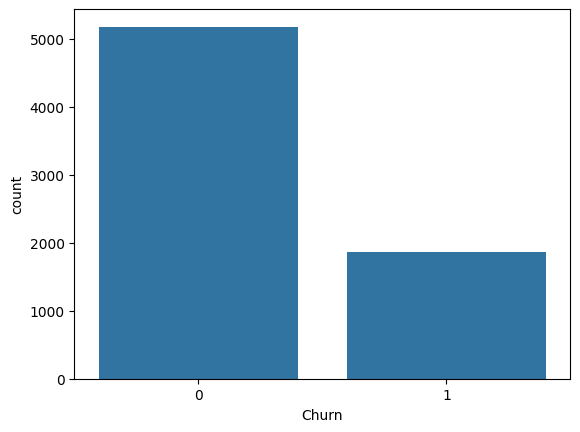

In [12]:
import seaborn as sns

sns.countplot(x='Churn', data=datos_final)

In [13]:
datos_final['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

####**SMOTE (Synthetic Minority Over-sampling Technique)**
es una técnica de sobremuestreo utilizada en problemas de clasificación desbalanceados para equilibrar la distribución de las clases. En situaciones donde una clase es mucho más predominante que las otras, los modelos de aprendizaje automático pueden tener dificultades para aprender patrones de las clases minoritarias.

SMOTE aborda este problema generando nuevas muestras sintéticas de la clase minoritaria en el espacio de características. Esto se hace mediante la interpolación entre muestras de la clase minoritaria cercanas. De esta manera, SMOTE ayuda a evitar el sobreajuste que puede ocurrir con simples técnicas de sobremuestreo, como la replicación de instancias, al introducir variedad adicional en los datos de entrenamiento.

En resumen, SMOTE es útil para mejorar el rendimiento de los modelos de aprendizaje automático en conjuntos de datos desbalanceados al equilibrar la distribución de las clases mediante la generación de muestras sintéticas de la clase minoritaria.

In [14]:
from imblearn.over_sampling import SMOTE

# Crea una matriz X sin la columna 'Churn'
X = datos_final.drop(columns=['Churn'], axis=1)
# Crea un vector y con la columna 'Churn'
y = datos_final['Churn']

# Inicializa el objeto SMOTE con un estado aleatorio fijo para reproducibilidad
smt = SMOTE(random_state=123)
# Aplica SMOTE para sobremuestrear X e y y equilibrar las clases
X, y = smt.fit_resample(X, y)

In [15]:
datos_final.shape

(7043, 39)

In [16]:
datos_final = pd.concat([X, y], axis=1)
datos_final.shape

(10348, 39)

In [17]:
datos_final.sample(5)

,Conyuge,Dependientes,TelefonoFijo,PagoOnline,Mayor65Anos,MesesDeContrato,CuentaMensual,VariasLineasTelefonicas_No,VariasLineasTelefonicas_Si,VariasLineasTelefonicas_SinServicioTelefonico,ServicioDeInternet_DSL,ServicioDeInternet_FibraOptica,ServicioDeInternet_No,SeguridadOnline_No,SeguridadOnline_Si,SeguridadOnline_SinServicioDeInternet,BackupOnline_No,BackupOnline_Si,BackupOnline_SinServicioDeInternet,SeguroEnDispositivo_No,SeguroEnDispositivo_Si,SeguroEnDispositivo_SinServicioDeInternet,SoporteTecnico_No,SoporteTecnico_Si,SoporteTecnico_SinServicioDeInternet,TVaCable_No,TVaCable_Si,TVaCable_SinServicioDeInternet,StreamingDePeliculas_No,StreamingDePeliculas_Si,StreamingDePeliculas_SinServicioDeInternet,TipoDeContrato_Anual,TipoDeContrato_Bienal,TipoDeContrato_Mensual,FormaDePago_ChequeDigital,FormaDePago_ChequePapel,FormaDePago_DebitoAutomatico,FormaDePago_TarjetaDeCredito,Churn
677,0,0,0,1,0,2,34,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1,1,0,0,0,1
7211,1,1,1,0,0,1,20,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,1,0,0,1
315,1,1,1,0,0,51,110,0,1,0,0,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,0,1,0,0,0,0,0,1,0
5873,0,0,1,1,0,18,75,1,0,0,0,1,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0
5978,0,0,1,0,0,46,84,0,1,0,0,1,0,0,1,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0


In [18]:
datos_final['Churn'].value_counts()

Churn
0    5174
1    5174
Name: count, dtype: int64

<Axes: xlabel='Churn', ylabel='count'>

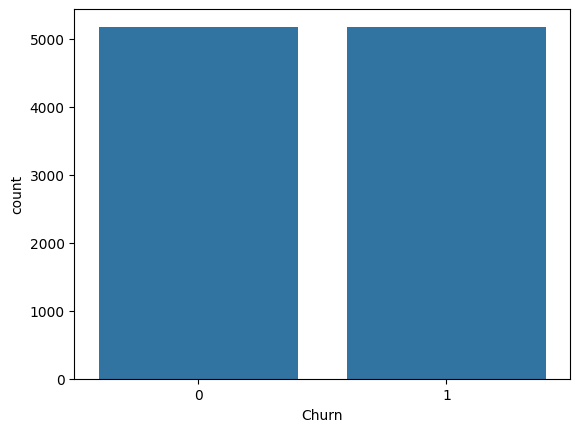

In [19]:
sns.countplot(x='Churn', data=datos_final)

## Aula 2

###**Modelo K-Nearest Neighbors (KNN)**
es un algoritmo de aprendizaje supervisado utilizado para clasificación y regresión. En la clasificación, KNN busca las K muestras de entrenamiento más cercanas en el espacio de características y predice la etiqueta de la clase más común entre ellas. En la regresión, KNN predice el valor objetivo promedio de las K muestras más cercanas.

KNN es un algoritmo simple y fácil de entender, pero puede ser computacionalmente costoso en conjuntos de datos grandes debido a la necesidad de calcular la distancia entre cada muestra de entrenamiento y la muestra de prueba. Es importante elegir un valor adecuado para K, ya que un valor demasiado pequeño puede hacer que el modelo sea sensible al ruido, mientras que un valor demasiado grande puede hacer que el modelo pierda detalles importantes en los datos.







### 2.2 KNN entre bastidores

In [20]:
Xmaria

[[0,
  0,
  1,
  1,
  0,
  0,
  39.9,
  1,
  0,
  0,
  0,
  1,
  0,
  1,
  0,
  0,
  0,
  0,
  1,
  1,
  1,
  0,
  0,
  1,
  0,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  0,
  1]]

In [21]:
# ymaria=?
X = datos_final.drop(columns=['Churn'], axis=1)
y = datos_final['Churn']

In [22]:
'''Ahora bien. Yo necesito que mis datos estén a la misma escala,
 como yo tengo 0 y 1, 0 y 1, y de repente tengo los meses de contrato,
 entonces tengo 24 o 36 meses.
[02:09] Entonces este valor puede perjudicar seriamente mi modelo,
 esta diferencia de valores o por ejemplo, si yo tengo también el valor
 de la cuenta mensual en 300, 400, entonces tengo 0 y 1, 0 y 1, y de repente
 300 y 400, eso también puede perjudicar mi resultado.
[02:26] Entonces lo que debemos hacer es estandarizar o sea,
 traer todo a una misma escala de valores, y para hacerlo entonces
 nosotros vamos a utilizar un paquete de SKLearn que se llama StandardScaler.
 Entonces toma el promedio y lo divide entre el desvío típico para
 obtener un valor dentro de la misma escala en todos nuestros atributos.
 '''
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

In [23]:
'''un array con los siguientes valores,
 cada uno de estos con cada uno de sus atributos'''
X_std[0]

array([ 1.27165114, -0.52875752, -3.06253774,  0.80941359, -0.40949022,
       -1.10803629, -1.33340616, -0.88378002, -0.83183864,  3.18604176,
        1.51441199, -1.04326198, -0.44617598,  0.86930072, -0.51871996,
       -0.44617598, -0.96076148,  1.57836246, -0.44617598,  1.04225252,
       -0.64301486, -0.44617598,  0.87979784, -0.52396679, -0.44617598,
        1.19022172, -0.77691391, -0.44617598,  1.20432168, -0.78863399,
       -0.44617598, -0.42116602, -0.44648735,  0.74054467,  1.29539717,
       -0.47958439, -0.43428742, -0.4271925 ])

In [24]:
Xmaria_std = scaler.transform(pd.DataFrame(Xmaria, columns=X.columns))
Xmaria_std

array([[-0.7863792 , -0.52875752,  0.32652659,  0.80941359, -0.40949022,
        -1.14971402, -0.95411127,  1.13150329, -0.83183864, -0.31386908,
        -0.6603223 ,  0.95853201, -0.44617598,  0.86930072, -0.51871996,
        -0.44617598, -0.96076148, -0.63356803,  2.24126814,  1.04225252,
         1.55517402, -0.44617598, -1.13662476,  1.9085179 , -0.44617598,
         1.19022172, -0.77691391, -0.44617598, -0.83034293, -0.78863399,
         2.24126814, -0.42116602, -0.44648735,  0.74054467, -0.77196401,
        -0.47958439, -0.43428742,  2.34086508]])

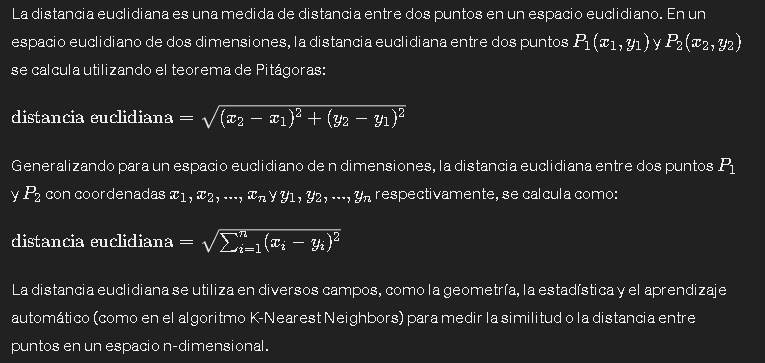

Distancia Euclidiana:

$$\sqrt{\sum_{i=1}^k(a_{i}-b_{i})^2}$$

In [25]:
import numpy as np

a = Xmaria_std
b = X_std[0]

distancia = np.sqrt(np.sum((a-b)**2))
print(f'la distancia euclidiana de maria con respecto al primer registro del data set es: {distancia}')

la distancia euclidiana de maria con respecto al primer registro del data set es: 9.54686064584311


### 2.3 Implementando el modelo KNN

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

In [27]:
# Modelo K-Nearest Neighbors (KNN)
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(metric= 'euclidean')
knn.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean')

In [28]:
prevision_knn= knn.predict(X_test)

In [29]:
prevision_knn

array([1, 0, 0, ..., 1, 1, 1])

#### ejercio
Ahora que ya conoces el modelo KNN y las métricas de distancia, ¡Llegó la hora de practicar!

Calcula la distancia de María con los(as) 10 primeros(as) clientes de nuestra base de datos estandarizada utilizando la métrica euclidiana.
$$\sqrt{\sum_{i=1}^k(a_{i}-b_{i})^2}$$

In [30]:
def calcula_distancia(datos_clientes, datos_maria, numero_clientes):
    distancias = []
    #loop para recorrer cliente por cliente
    for i in range(numero_clientes):
        dist1 = datos_maria - datos_clientes[i]     #sustracción de los atributos (a - b)
        suma_cuadrado = np.sum(np.square(dist1))    #exp. y suma de todos los atributos
        distancias.append(np.sqrt(suma_cuadrado))   #raiz cuadrada de la suma anterior
    return distancias

calcula_distancia(X_std, Xmaria_std, 10)

[9.54686064584311,
 9.397455820184899,
 8.45861018654057,
 10.40382404092556,
 7.102542013358195,
 8.338390803412617,
 8.030553895783607,
 10.136207400857487,
 8.110355961683732,
 10.07283058175244]

## Aula 3

### 3.3 Implementando el modelo Bernoulli Naive Bayes

In [31]:
mediana = np.median(X_train)

####**BernoulliNB**
 es un clasificador de Naïve Bayes implementado en la biblioteca scikit-learn de Python, específicamente diseñado para datos binarios o "bernoulli" (valores 0 o 1), donde cada característica representa una variable booleana. Este clasificador se basa en el modelo de distribución de Bernoulli, que es apropiado cuando las características son binarias.

Este clasificador asume que todas las características son independientes entre sí, dado el valor de la variable de clase, lo cual es una suposición simplificada pero útil para muchos problemas de clasificación.

Aquí hay un resumen de cómo funciona y para qué se usa:

**Funcionamiento:**

Modelo de distribución de Bernoulli: El clasificador de BernoulliNB modela la distribución de las características como variables binarias, donde cada característica puede tomar los valores 0 o 1.
Suposición de independencia condicional: Al igual que otros clasificadores Naïve Bayes, asume que las características son condicionalmente independientes entre sí, dado el valor de la variable de clase.

**Aplicaciones y uso:**

Clasificación de texto binario: Es comúnmente utilizado en tareas de clasificación de texto donde las características representan la presencia o ausencia de palabras clave.
Filtrado de documentos: Puede ser útil en sistemas de filtrado de documentos, donde se necesita clasificar documentos como relevantes o irrelevantes.
Clasificación de imágenes binarias: También puede aplicarse en tareas de clasificación de imágenes binarias, donde las características representan la presencia o ausencia de ciertas características visuales.

**Ventajas:**

Eficiencia computacional: Es computacionalmente eficiente y puede manejar grandes conjuntos de datos con muchas características.
Fácil de usar e implementar: Es fácil de entender e implementar, lo que lo hace adecuado para problemas de clasificación binaria simples.

**Limitaciones:**

Suposición de independencia condicional: La suposición de independencia entre las características puede no ser válida en todos los casos, lo que puede afectar el rendimiento del clasificador en conjuntos de datos donde las características están correlacionadas.

Sensibilidad a la binarización:

 Dado que funciona mejor con datos binarios, puede ser menos efectivo en conjuntos de datos con características continuas o categóricas con más de dos categorías.
En resumen, BernoulliNB es útil cuando se trabaja con datos binarios y se desea un clasificador simple y eficiente para la clasificación de textos, filtrado de documentos u otras tareas similares. Sin embargo, es importante considerar sus suposiciones y limitaciones al aplicarlo a un problema específico.

In [32]:
from sklearn.naive_bayes import BernoulliNB

bnb = BernoulliNB(binarize=mediana)
bnb.fit(X_train, y_train)

BernoulliNB()

In [33]:
prevision_bnb = bnb.predict(X_test)

In [34]:
prevision_bnb

array([1, 0, 0, ..., 1, 1, 1])

## Aula 4

### 4.3 Implementando el modelo de Árbol de Decisión

####**DecisionTreeClassifier**
es una clase en la biblioteca de Python scikit-learn (sklearn) que se utiliza para construir modelos de clasificación basados en árboles de decisión. Un árbol de decisión es una estructura de árbol en la que cada nodo interno representa una "decisión" basada en una característica (atributo), cada rama representa el resultado de esa decisión y cada nodo hoja representa una etiqueta de clase. El objetivo de un clasificador de árbol de decisión es crear un modelo que prediga la etiqueta de clase correcta para nuevos ejemplos en función de las características que poseen.

DecisionTreeClassifier se utiliza comúnmente en problemas de clasificación en los que se busca predecir la pertenencia a una o varias clases en función de ciertas características. Por ejemplo, podría utilizarse para predecir si un correo electrónico es spam o no spam en función de ciertas palabras clave presentes en el correo electrónico.

In [35]:
from sklearn.tree import DecisionTreeClassifier
'''l árbol de decisión no necesita que nosotros realicemos el preprocesamiento
 de estandarizar nuestros datos. Él va tomando las decisiones independientemente
 de si la escala está igual o no, entonces no necesitamos utilizar datos estandarizados.
Lo mismo, las variables categóricas él las recibe tal cual.
 Entonces tampoco necesitamos hacer este cambio de variables categóricas a
 numéricas, a través de los dummies, él de una vez reconoce esto, entonces
 en ese sentido, el árbol de decisión es robusto cuando no preprocesamos nuestros
 datos, cuando no realizamos estas fases de preprocesamiento.'''
dt = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=3)
dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)


dt.feature_importances_ es un atributo de un modelo de árbol de decisión en scikit-learn que muestra la importancia de cada característica (atributo) en la toma de decisiones del modelo. La importancia de una característica se calcula como la reducción total de la impureza (como Gini impurity o entropy) que proporciona esa característica al realizar divisiones en el árbol.

Cuando se entrena un modelo de árbol de decisión en scikit-learn, después del entrenamiento, puedes acceder a dt.feature_importances_ si dt es tu modelo entrenado. Esto devuelve un array que contiene la importancia de cada característica, donde el índice del array corresponde al índice de la característica en tus datos de entrenamiento.

In [36]:
dt.feature_importances_

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.1183405 , 0.00880484, 0.        , 0.        , 0.        ,
       0.        , 0.08847472, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.21304108, 0.10660297, 0.46473589, 0.        ,
       0.        , 0.        , 0.        ])

In [37]:
prevision_dt = dt.predict(X_test)

In [38]:
prevision_dt

array([1, 0, 0, ..., 1, 1, 1])

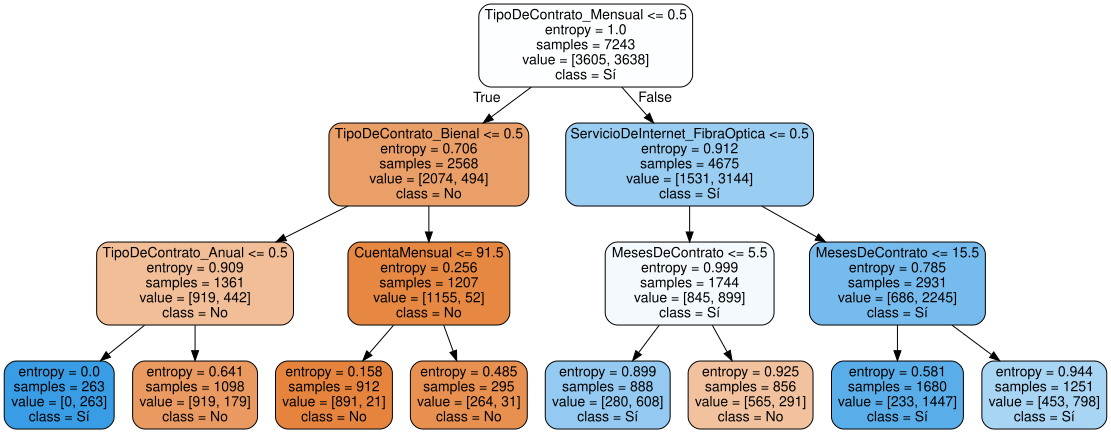

In [39]:
from sklearn.tree import export_graphviz
import graphviz

features = X.columns
dot_data = export_graphviz(dt, feature_names=features, filled=True, rounded=True, class_names=['No','Sí'])
grafico = graphviz.Source(dot_data)
grafico

## Aula 5

### 5.1 Matriz de Confusión

![img](https://miro.medium.com/max/799/1*XsFcyoLXNdAkbSfNGnxhEg.png)

In [ ]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, prevision_knn))

[[1115  454]
 [ 149 1387]]


In [ ]:
print(confusion_matrix(y_test, prevision_bnb))

[[1076  493]
 [ 235 1301]]


In [ ]:
print(confusion_matrix(y_test, prevision_dt))

[[1252  317]
 [ 286 1250]]


### 5.2 Exactitud

> A partir del cálculo de la matriz de confusión logramos inferir otras métricas, como por ejemplo la exactitud.

$exactitud$ = ${TP + TN \over TP + FP + TN + FN}$

In [ ]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, prevision_knn))

0.8057971014492754


In [ ]:
print(accuracy_score(y_test, prevision_bnb))

0.7655394524959742


In [ ]:
print(accuracy_score(y_test, prevision_dt))

0.8057971014492754


### 5.3 Precisión

> Otra métrica importante es la precisión, que calcula cuántas observaciones fueron clasificadas correctamente como positivas ($TP$).

$precision$ = ${TP \over TP + FP}$

In [ ]:
from sklearn.metrics import precision_score

print(precision_score(y_test, prevision_knn))

0.7533948940793047


In [ ]:
print(precision_score(y_test, prevision_bnb))

0.7251950947603122


In [ ]:
print(precision_score(y_test, prevision_dt))

0.797702616464582


### 5.4 Recall

> Además, existe una métrica conocida como Recall o sensibilidad, que calcula qué tan bien el modelo clasifica correctamente un resultado positivo ($TP$).

$recall$ = ${TP \over TP + FN}$


In [ ]:
from sklearn.metrics import recall_score

print(recall_score(y_test, prevision_knn))

0.9029947916666666


In [ ]:
print(recall_score(y_test, prevision_bnb))

0.8470052083333334


In [ ]:
print(recall_score(y_test, prevision_dt))

0.8138020833333334
